# Day 05：复仇之战 —— LSTM vs RNN 的终极对决> ⏳ 第九周 · 记忆的诞生 · 第 5 天前四天，我们从"金鱼记忆"出发，认识了 RNN，发现了它的梯度消失问题，然后学习了 LSTM 的门控机制。今天是验收成果的时刻：**LSTM 能否在长距离依赖任务上碾压 RNN？****今天的任务**：1. 在长距离依赖任务上对比 RNN 和 LSTM2. 可视化两者的记忆能力差异3. 绘制"记忆衰减曲线"，直观感受 LSTM 的优势---

## 1. 历史剧场：LSTM 统治序列建模的 20 年从 1997 年被提出到 2017 年 Transformer 诞生，LSTM 统治了序列建模领域整整 20 年：- **语音识别**：2012-2015 年，所有顶级语音系统都用 LSTM- **机器翻译**：Google Translate 2016 年的升级就是用 LSTM- **文本生成**：早期 AI 写作都是基于 LSTM- **时间序列预测**：股票、天气、流量预测的首选LSTM 之所以能统治这么久，就是因为它解决了 RNN 的"金鱼记忆"问题。---

## 2. 生活隐喻：金鱼 vs 大象- **RNN = 金鱼**：只有 7 秒记忆，刚看到的信息转眼就忘- **LSTM = 大象**：据说大象从不遗忘——LSTM 的细胞状态让关键信息可以穿越时间当然，LSTM 不是"什么都记住"——遗忘门让它能主动丢弃不再需要的信息。它更像一个**有选择性的大象**：重要的永远不忘，不重要的主动忘记。---

<p align="center">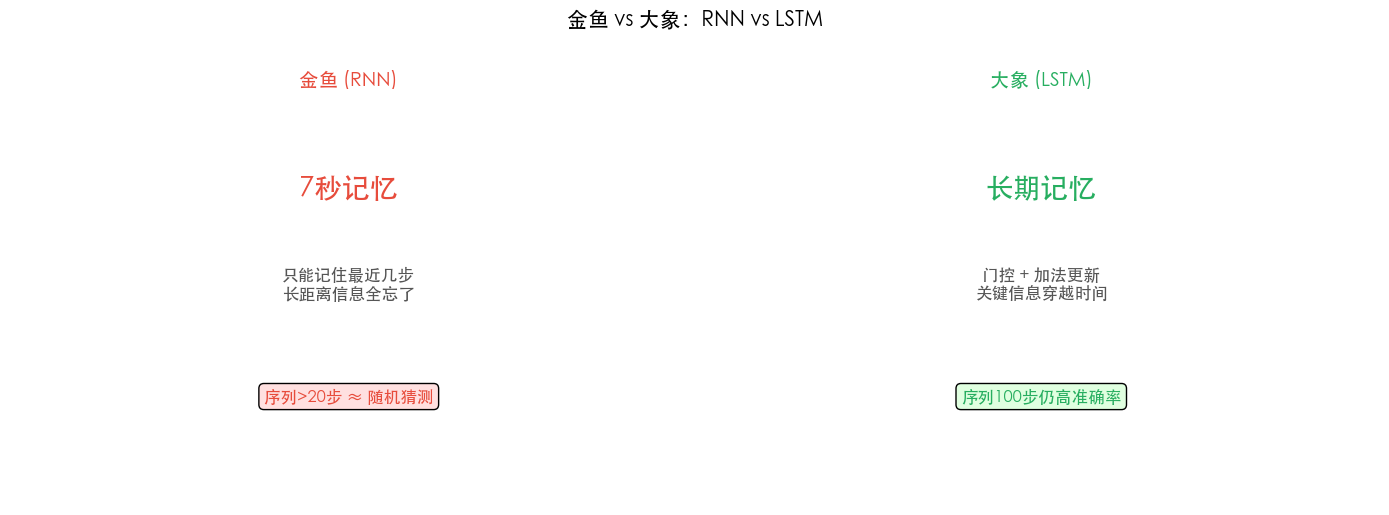</p>*RNN金鱼 vs LSTM大象对比图*

## 3. 代码实验室：RNN vs LSTM 全面对决

In [ ]:
import torchimport torch.nn as nnimport matplotlib.pyplot as pltimport numpy as npplt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']plt.rcParams['axes.unicode_minus'] = False

### 3.1 任务：长距离依赖回忆

In [ ]:
def create_recall_data(seq_len=50, n_samples=300):    np.random.seed(42)    X = np.random.randn(n_samples, seq_len, 1).astype(np.float32)    y = (X[:, 0, 0] > 0).astype(np.float32).reshape(-1, 1)    noise = np.random.randn(*X.shape) * 0.1    X = X + noise    return torch.tensor(X), torch.tensor(y)

### 3.2 定义模型

In [ ]:
class RNNModel(nn.Module):    def __init__(self, input_size=1, hidden_size=64):        super().__init__()        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)        self.fc = nn.Linear(hidden_size, 1)    def forward(self, x):        _, h_n = self.rnn(x)        return torch.sigmoid(self.fc(h_n.squeeze(0)))class LSTMModel(nn.Module):    def __init__(self, input_size=1, hidden_size=64):        super().__init__()        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)        self.fc = nn.Linear(hidden_size, 1)    def forward(self, x):        _, (h_n, _) = self.lstm(x)        return torch.sigmoid(self.fc(h_n.squeeze(0)))def train_model(model, X, y, epochs=300, lr=0.005):    optimizer = torch.optim.Adam(model.parameters(), lr=lr)    loss_fn = nn.BCELoss()    losses = []    for epoch in range(epochs):        pred = model(X)        loss = loss_fn(pred, y)        optimizer.zero_grad()        loss.backward()        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)        optimizer.step()        losses.append(loss.item())    acc = ((pred > 0.5).float() == y).float().mean()    return losses, acc.item()

### 3.3 不同序列长度的对决

In [ ]:
seq_lengths = [5, 10, 20, 40, 60, 80, 100]rnn_accs = []lstm_accs = []for sl in seq_lengths:    X, y = create_recall_data(seq_len=sl)    torch.manual_seed(42)    rnn_model = RNNModel()    _, rnn_acc = train_model(rnn_model, X, y)    rnn_accs.append(rnn_acc)    torch.manual_seed(42)    lstm_model = LSTMModel()    _, lstm_acc = train_model(lstm_model, X, y)    lstm_accs.append(lstm_acc)    print(f"序列长度={sl:3d}: RNN={rnn_acc:.2%}, LSTM={lstm_acc:.2%}")

### 3.4 可视化：记忆衰减曲线

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))axes[0].plot(seq_lengths, rnn_accs, 'o-', color='#e74c3c', label='RNN (金鱼记忆)', lw=2, markersize=8)axes[0].plot(seq_lengths, lstm_accs, 's-', color='#27ae60', label='LSTM (大象记忆)', lw=2, markersize=8)axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='随机猜测')axes[0].set_xlabel('序列长度', fontsize=13)axes[0].set_ylabel('准确率', fontsize=13)axes[0].set_title('记忆衰减曲线：RNN vs LSTM', fontsize=15)axes[0].legend(fontsize=12)axes[0].grid(True, alpha=0.3)axes[0].set_ylim(0.4, 1.05)X_long, y_long = create_recall_data(seq_len=60)torch.manual_seed(42)rnn_long = RNNModel()rnn_losses, _ = train_model(rnn_long, X_long, y_long)torch.manual_seed(42)lstm_long = LSTMModel()lstm_losses, _ = train_model(lstm_long, X_long, y_long)axes[1].plot(rnn_losses, color='#e74c3c', label='RNN', alpha=0.8)axes[1].plot(lstm_losses, color='#27ae60', label='LSTM', alpha=0.8)axes[1].set_xlabel('Epoch', fontsize=13)axes[1].set_ylabel('Loss', fontsize=13)axes[1].set_title('长序列 (T=60) 训练损失对比', fontsize=15)axes[1].legend(fontsize=12)axes[1].grid(True, alpha=0.3)plt.tight_layout()plt.show()

### 解读- **记忆衰减曲线**：RNN 的准确率随序列长度急剧下降，LSTM 则保持稳定- **训练损失**：RNN 在长序列上几乎学不动，LSTM 则能稳定收敛- **结论**：LSTM 的门控机制让它在长距离依赖任务上碾压 RNN---

## 4. 深度分析：为什么 LSTM 能赢？

In [ ]:
print("RNN vs LSTM：为什么 LSTM 能记住长距离信息？\n")print("RNN 的记忆更新：")print("  h_t = tanh(W @ [h_{t-1}, x_t] + b)")print("  问题：每步都经过 tanh 压缩，信息逐步衰减\n")print("LSTM 的记忆更新：")print("  C_t = f_t * C_{t-1} + i_t * C_tilde")print("  关键：加法更新！类似 ResNet 的 F(x) + x")print("  当 f_t ≈ 1 时，C_t ≈ C_{t-1}，信息无损传递\n")print("这就是 LSTM 能记住长距离信息的数学根源：")print("  加法 = 梯度保底 = 信息高速公路")print("  和 ResNet 的跳跃连接是同一个思想！")

---

## 今日结语今天我们见证了 LSTM 对 RNN 的碾压级胜利。在长距离依赖任务上：- **RNN**：序列越长越健忘，超过 20 步就接近随机猜测- **LSTM**：即使序列长达 100 步，仍能保持高准确率LSTM 赢在**细胞状态的加法更新**——这和 ResNet 的跳跃连接是同一个思想：加法让梯度保底，让信息无损传递。下周，我们将深入 LSTM 的更多细节，并实战应用。---### 翻译词典| 生活中的直觉 | 深度学习术语 ||---|---|| 金鱼 vs 大象 | RNN vs LSTM——短记忆 vs 长记忆 || 有选择性的大象 | LSTM 的遗忘门——主动遗忘不需要的信息 || 记忆随时间衰减 | RNN 的梯度消失 || 记忆可以穿越时间 | LSTM 的加法更新——梯度保底 || 同一个思想：抄近道 | ResNet 的 F(x)+x ≈ LSTM 的 C_t = f*C_{t-1} + i*C̃ |